In [33]:
#imports

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.metrics import roc_auc_score

np.random.seed(42)

In [34]:
#simulate dataset

n_users = 75
n_days = 180
start_date = datetime(2025, 10, 1)

users = pd.DataFrame({
    "user_id": range(1, n_users + 1),
    "fitness_level": np.random.choice(["beginner", "intermediate", "advanced"], size=n_users, p=[0.3, 0.5, 0.2]),
    "primary_activity": np.random.choice(["weightlifting", "yoga", "pilates", "running", "mixed"], size=n_users)
})

rows = []

for _, user in users.iterrows():
    baseline_sleep = np.random.normal(7.2, 0.6)
    baseline_steps = np.random.normal(8500, 1800)
    baseline_performance = np.random.normal(75, 8)
    fatigue = np.random.normal(30, 8)

    consecutive_training_days = 0

    for i in range(n_days):
        current_date = start_date + timedelta(days=i)
        dow = current_date.weekday()

        # More likely to rest occasionally
        rest_day = np.random.rand() < 0.2
        workout_type = "rest" if rest_day else np.random.choice(
            ["weightlifting", "yoga", "pilates", "cardio"],
            p=[0.4, 0.2, 0.15, 0.25]
        )

        if rest_day:
            workout_duration = 0
            workout_intensity = 0
            calories_burned = np.random.normal(1800, 120)
            consecutive_training_days = 0
        else:
            workout_duration = max(20, np.random.normal(60, 15))
            workout_intensity = np.random.randint(4, 10)
            calories_burned = np.random.normal(2200 + 45 * workout_intensity, 150)
            consecutive_training_days += 1

        sleep_hours = np.clip(
            baseline_sleep - 0.08 * max(consecutive_training_days - 2, 0) + np.random.normal(0, 0.7),
            4.2,
            9.5
        )

        steps = max(1500, np.random.normal(baseline_steps + 400 * (workout_type == "cardio"), 1400))
        soreness_score = np.clip(np.random.normal(3 + 0.5 * workout_intensity if not rest_day else 2, 1.4), 1, 10)
        stress_score = np.clip(np.random.normal(4.5 + 0.12 * fatigue, 1.5), 1, 10)
        hydration_level = np.clip(np.random.normal(3.0, 0.6), 1, 5)

        # Fatigue rises with training load and poor recovery
        fatigue = np.clip(
            fatigue + 1.3 * workout_intensity - 1.8 * (sleep_hours - 7) - 3.5 * rest_day + np.random.normal(0, 3),
            5,
            95
        )

        recovery_score = np.clip(
            70 + 5 * (sleep_hours - 7) - 0.45 * fatigue - 0.8 * soreness_score + 1.5 * hydration_level + np.random.normal(0, 4),
            0,
            100
        )

        performance_score = np.clip(
            baseline_performance + 2.4 * (sleep_hours - 7) - 0.35 * fatigue + 0.18 * recovery_score + np.random.normal(0, 5),
            35,
            100
        )

        rows.append({
            "user_id": user["user_id"],
            "date": current_date,
            "fitness_level": user["fitness_level"],
            "primary_activity": user["primary_activity"],
            "workout_type": workout_type,
            "rest_day_flag": int(rest_day),
            "workout_duration": round(workout_duration, 1),
            "workout_intensity": workout_intensity,
            "sleep_hours": round(sleep_hours, 2),
            "steps": int(steps),
            "calories_burned": int(calories_burned),
            "soreness_score": round(soreness_score, 1),
            "stress_score": round(stress_score, 1),
            "hydration_level": round(hydration_level, 1),
            "fatigue_level": round(fatigue, 1),
            "recovery_score": round(recovery_score, 1),
            "performance_score": round(performance_score, 1),
            "consecutive_training_days": consecutive_training_days,
            "day_of_week": dow
        })

performance_df = pd.DataFrame(rows).sort_values(["user_id", "date"]).reset_index(drop=True)


In [35]:
# intentional dirty data

issue_idx = np.random.choice(performance_df.index, size=50, replace=False)
performance_df.loc[issue_idx[:15], "sleep_hours"] = np.nan
performance_df.loc[issue_idx[15:30], "steps"] = -1
performance_df.loc[issue_idx[30:40], "workout_type"] = "YOGA"
performance_df = pd.concat([performance_df, performance_df.sample(10, random_state=42)], ignore_index=True)

In [36]:
# data cleaning

df = performance_df.copy()

# remove duplicates
df = df.drop_duplicates()

# standardize text labels
df["workout_type"] = df["workout_type"].str.lower().replace({"yoga": "yoga"})

# replace invalid steps
df.loc[df["steps"] < 0, "steps"] = np.nan

# impute missing numeric values by user median, then overall median
for col in ["sleep_hours", "steps"]:
    df[col] = df.groupby("user_id")[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

In [37]:
# feature engineering

df = df.sort_values(["user_id", "date"]).reset_index(drop=True)

grouped = df.groupby("user_id")

df["prev_day_performance"] = grouped["performance_score"].shift(1)
df["prev_day_sleep"] = grouped["sleep_hours"].shift(1)
df["sleep_7d_avg"] = grouped["sleep_hours"].transform(lambda s: s.rolling(7, min_periods=1).mean())
df["fatigue_7d_avg"] = grouped["fatigue_level"].transform(lambda s: s.rolling(7, min_periods=1).mean())
df["workload"] = df["workout_duration"] * df["workout_intensity"]
df["recovery_to_workload_ratio"] = df["recovery_score"] / (df["workload"] + 1)
df["low_sleep_flag"] = (df["sleep_hours"] < 6).astype(int)
df["high_fatigue_flag"] = (df["fatigue_level"] > 70).astype(int)
df["performance_change"] = df["performance_score"] - df["prev_day_performance"]

df["performance_drop_flag"] = (df["performance_change"] < -6).astype(int)
df["burnout_risk_score"] = (
    0.35 * (100 - df["recovery_score"]) +
    0.30 * df["fatigue_level"] +
    0.20 * (7 - df["sleep_hours"]).clip(lower=0) * 10 +
    0.15 * (df["consecutive_training_days"] * 8).clip(upper=100)
).clip(0, 100)

df["burnout_risk_label"] = pd.cut(
    df["burnout_risk_score"],
    bins=[-0.1, 33, 66, 100],
    labels=["low", "medium", "high"]
)

# Fill lag-based nulls after shifts
for col in ["prev_day_performance", "prev_day_sleep", "performance_change"]:
    df[col] = df[col].fillna(df[col].median())


In [38]:
#save csv's

users.to_csv("users.csv", index=False)
df.to_csv("human_performance_burnout_dataset.csv", index=False)

print("Saved:")
print("- /mnt/data/users.csv")
print("- /mnt/data/human_performance_burnout_dataset.csv")
print(df.head())

Saved:
- /mnt/data/users.csv
- /mnt/data/human_performance_burnout_dataset.csv
   user_id       date fitness_level primary_activity   workout_type  \
0        1 2025-10-01  intermediate          pilates  weightlifting   
1        1 2025-10-02  intermediate          pilates           yoga   
2        1 2025-10-03  intermediate          pilates           rest   
3        1 2025-10-04  intermediate          pilates        pilates   
4        1 2025-10-05  intermediate          pilates        pilates   

   rest_day_flag  workout_duration  workout_intensity  sleep_hours   steps  \
0              0              47.3                  5         6.27  8215.0   
1              0              92.4                  6         5.88  6639.0   
2              1               0.0                  0         6.86  6992.0   
3              0              23.0                  4         7.19  9036.0   
4              0              77.9                  6         7.55  8770.0   

   ...  sleep_7d_avg  fat

In [39]:
# print dataset overview

print("Dataset shape:", df.shape)

print("Columns:")
print(df.columns.tolist())

print("Missing values:")
print(df.isnull().sum())

print("Burnout risk label counts:")
print(df["burnout_risk_label"].value_counts())

print("Performance drop rate:", round(df["performance_drop_flag"].mean(), 3))

Dataset shape: (13500, 31)
Columns:
['user_id', 'date', 'fitness_level', 'primary_activity', 'workout_type', 'rest_day_flag', 'workout_duration', 'workout_intensity', 'sleep_hours', 'steps', 'calories_burned', 'soreness_score', 'stress_score', 'hydration_level', 'fatigue_level', 'recovery_score', 'performance_score', 'consecutive_training_days', 'day_of_week', 'prev_day_performance', 'prev_day_sleep', 'sleep_7d_avg', 'fatigue_7d_avg', 'workload', 'recovery_to_workload_ratio', 'low_sleep_flag', 'high_fatigue_flag', 'performance_change', 'performance_drop_flag', 'burnout_risk_score', 'burnout_risk_label']
Missing values:
user_id                       0
date                          0
fitness_level                 0
primary_activity              0
workout_type                  0
rest_day_flag                 0
workout_duration              0
workout_intensity             0
sleep_hours                   0
steps                         0
calories_burned               0
soreness_score       

In [40]:
# model setup and preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt

model_df = df.copy()

feature_cols = [
    "fitness_level", "primary_activity", "workout_type", "rest_day_flag",
    "workout_duration", "workout_intensity", "sleep_hours", "steps",
    "calories_burned", "soreness_score", "stress_score", "hydration_level",
    "fatigue_level", "recovery_score", "consecutive_training_days", "day_of_week",
    "prev_day_performance", "prev_day_sleep", "sleep_7d_avg", "fatigue_7d_avg",
    "low_sleep_flag", "high_fatigue_flag"
]

X = model_df[feature_cols]
y_reg = model_df["performance_score"]
y_clf = model_df["performance_drop_flag"]

categorical_features = ["fitness_level", "primary_activity", "workout_type"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

In [41]:
# regression models

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

linreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=150, random_state=42, max_depth=10))
])

linreg_pipeline.fit(X_train_reg, y_train_reg)
rf_reg_pipeline.fit(X_train_reg, y_train_reg)

linreg_preds = linreg_pipeline.predict(X_test_reg)
rf_reg_preds = rf_reg_pipeline.predict(X_test_reg)

print("--- Regression Results ---")
print("Linear Regression  MAE:", round(mean_absolute_error(y_test_reg, linreg_preds), 3))
print("Linear Regression  RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, linreg_preds)), 3))
print("Linear Regression  R2:", round(r2_score(y_test_reg, linreg_preds), 3))
print()
print("Random Forest  MAE:", round(mean_absolute_error(y_test_reg, rf_reg_preds), 3))
print("Random Forest  RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, rf_reg_preds)), 3))
print("Random Forest  R2:", round(r2_score(y_test_reg, rf_reg_preds), 3))

--- Regression Results ---
Linear Regression  MAE: 4.925
Linear Regression  RMSE: 6.177
Linear Regression  R2: 0.628

Random Forest  MAE: 4.74
Random Forest  RMSE: 5.943
Random Forest  R2: 0.656


In [42]:
# classification models

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# FIX 1: class_weight='balanced' tells the model burnout cases matter more
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

rf_clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150, random_state=42, max_depth=10,
        class_weight="balanced"  # FIX 1
    ))
])

logreg_pipeline.fit(X_train_clf, y_train_clf)
rf_clf_pipeline.fit(X_train_clf, y_train_clf)

logreg_preds = logreg_pipeline.predict(X_test_clf)
rf_clf_preds = rf_clf_pipeline.predict(X_test_clf)

# FIX 2: get probabilities and apply lower threshold (0.35 instead of 0.5)
rf_probs = rf_clf_pipeline.predict_proba(X_test_clf)[:, 1]
rf_clf_preds_tuned = (rf_probs >= 0.35).astype(int)

print("--- Classification Results (default threshold = 0.5) ---")
print("Logistic Regression Accuracy:", round(accuracy_score(y_test_clf, logreg_preds), 3))
print("Random Forest Accuracy:", round(accuracy_score(y_test_clf, rf_clf_preds), 3))
print()
print("Random Forest Classification Report (default threshold):")
print(classification_report(y_test_clf, rf_clf_preds))

# FIX 3: ROC-AUC is your new headline metric
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test_clf, rf_probs), 3))

print()
print("--- Random Forest (tuned threshold = 0.35) ---")
print(classification_report(y_test_clf, rf_clf_preds_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test_clf, rf_probs), 3))


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Classification Results (default threshold = 0.5) ---
Logistic Regression Accuracy: 0.741
Random Forest Accuracy: 0.741

Random Forest Classification Report (default threshold):
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      2141
           1       0.43      0.74      0.54       559

    accuracy                           0.74      2700
   macro avg       0.67      0.74      0.68      2700
weighted avg       0.81      0.74      0.76      2700

Random Forest ROC-AUC: 0.823

--- Random Forest (tuned threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.96      0.54      0.69      2141
           1       0.34      0.91      0.50       559

    accuracy                           0.62      2700
   macro avg       0.65      0.73      0.59      2700
weighted avg       0.83      0.62      0.65      2700

ROC-AUC: 0.823


In [43]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

rf_clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=150, random_state=42, max_depth=10))
])

logreg_pipeline.fit(X_train_clf, y_train_clf)
rf_clf_pipeline.fit(X_train_clf, y_train_clf)

logreg_preds = logreg_pipeline.predict(X_test_clf)
rf_clf_preds = rf_clf_pipeline.predict(X_test_clf)

print("--- Classification Results ---")
print("Logistic Regression Accuracy:", round(accuracy_score(y_test_clf, logreg_preds), 3))
print("Random Forest Accuracy:", round(accuracy_score(y_test_clf, rf_clf_preds), 3))
print("Random Forest Classification Report:")
print(classification_report(y_test_clf, rf_clf_preds))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Classification Results ---
Logistic Regression Accuracy: 0.815
Random Forest Accuracy: 0.818
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.90      2141
           1       0.73      0.19      0.30       559

    accuracy                           0.82      2700
   macro avg       0.78      0.59      0.60      2700
weighted avg       0.80      0.82      0.77      2700



In [46]:
# HistGradientBoostingClassifier

from sklearn.ensemble import HistGradientBoostingClassifier

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        max_depth=6,
        learning_rate=0.1,
        class_weight="balanced",
        random_state=42
    ))
])

hgb_pipeline.fit(X_train_clf, y_train_clf)
hgb_probs = hgb_pipeline.predict_proba(X_test_clf)[:, 1]
hgb_preds_tuned = (hgb_probs >= 0.35).astype(int)

print("--- HistGradientBoosting (tuned threshold = 0.35) ---")
print(classification_report(y_test_clf, hgb_preds_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test_clf, hgb_probs), 3))

--- HistGradientBoosting (tuned threshold = 0.35) ---
              precision    recall  f1-score   support

           0       0.96      0.57      0.71      2141
           1       0.35      0.91      0.51       559

    accuracy                           0.64      2700
   macro avg       0.66      0.74      0.61      2700
weighted avg       0.83      0.64      0.67      2700

ROC-AUC: 0.84


Top regression features:                            feature  importance
13       num__prev_day_performance    0.622827
10             num__recovery_score    0.101713
9               num__fatigue_level    0.050327
3                 num__sleep_hours    0.049593
14             num__prev_day_sleep    0.044697
4                       num__steps    0.015975
15               num__sleep_7d_avg    0.015815
5             num__calories_burned    0.014541
6              num__soreness_score    0.010409
16             num__fatigue_7d_avg    0.010391
1            num__workout_duration    0.009421
22     cat__primary_activity_mixed    0.009087
8             num__hydration_level    0.008725
20     cat__fitness_level_beginner    0.004727
11  num__consecutive_training_days    0.004594


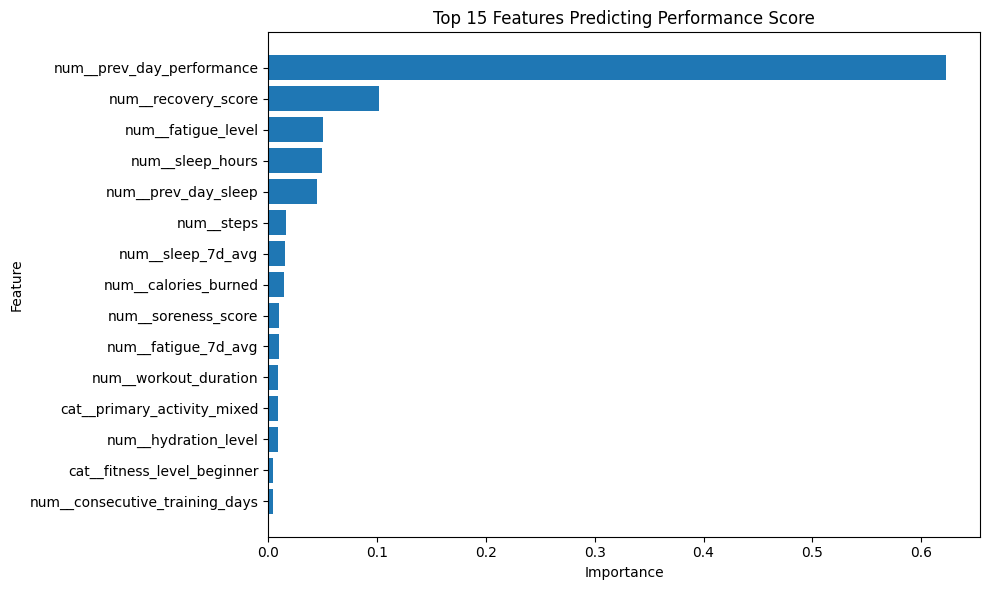

In [47]:
# regression (feature importance)

feature_names = rf_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_reg_pipeline.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

print("Top regression features:", importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Predicting Performance Score")
plt.tight_layout()
plt.show()

In [48]:
# save outputs

importance_df.to_csv("feature_importance_top15.csv", index=False)
print("Saved: feature_importance_top15.csv")

Saved: feature_importance_top15.csv
